<a href="https://colab.research.google.com/github/judithjosephantony/Group-Project/blob/main/calculating_lyapunov_exponent_and_time_for_lorentz_and_rossler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculating the Lyapunov Exponent

This script computes the largest Lyapunov exponent using
the Benettin algorithm.


------

For a nonlinear ODE system:

    dx/dt = f(x)

Nearby trajectories separate as:

    ||δx(t)|| ≈ ||δx(0)|| * exp(λ t)

The largest Lyapunov exponent is:

    λ = (1/T) * Σ log(||δ_k|| / ||δ_0||)

The Lyapunov time (predictability timescale) is:

    T_L = 1 / λ




In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

Lorenz equations:

dx/dt = σ(y − x)

dy/dt = x(ρ − z) − y

dz/dt = xy − βz

Standard chaotic parameters:

σ = 10

ρ = 28

β = 8/3

In [ ]:
def lyapunov_exponent(f, jacobian, x0, dt=0.01, T=100, delta0=1e-8):
    """
    Computes the largest Lyapunov exponent of an ODE system
    using the Benettin method.

    Parameters:
    f          : function defining the ODE (dx/dt = f(x))
    jacobian   : function returning Jacobian matrix J(x)
    x0         : initial condition (array-like)
    dt         : renormalization time step
    T          : total integration time
    delta0     : initial perturbation magnitude

    Returns:
    lambda_max : largest Lyapunov exponent
    """

    x = np.array(x0, dtype=float)
    dim = len(x)

    # Initial perturbation vector
    delta = np.random.rand(dim)
    delta = delta0 * delta / np.linalg.norm(delta)

    lyap_sum = 0.0
    steps = int(T / dt)

    for _ in range(steps):

        # Integrate main system
        sol = solve_ivp(lambda t, y: f(y), [0, dt], x)
        x = sol.y[:, -1]

        # Integrate tangent system
        sol_delta = solve_ivp(
            lambda t, y: jacobian(x) @ y,
            [0, dt],
            delta
        )
        delta = sol_delta.y[:, -1]

        # Compute growth factor
        norm = np.linalg.norm(delta)
        lyap_sum += np.log(norm / delta0)

        # Renormalize
        delta = delta0 * delta / norm

    lambda_max = lyap_sum / T
    return lambda_max


In [ ]:
def lorenz(x, sigma=10, rho=28, beta=8/3):
    return np.array([
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2]
    ])

def lorenz_jacobian(x, sigma=10, rho=28, beta=8/3):
    return np.array([
        [-sigma, sigma, 0],
        [rho - x[2], -1, -x[0]],
        [x[1], x[0], -beta]
    ])

In [ ]:
x0 = [1.0, 1.0, 1.0]

lambda_lorenz = lyapunov_exponent(
    lorenz,
    lorenz_jacobian,
    x0,
    dt=0.01,
    T=100
)

T_L_lorenz = 1 / lambda_lorenz

print("Lorenz Lyapunov exponent:", lambda_lorenz)
print("Lorenz Lyapunov time:", T_L_lorenz)


Lorenz Lyapunov exponent: 0.8097514812773561
Lorenz Lyapunov time: 1.2349467992605994


Rössler equations:

dx/dt = -y - z

dy/dt = x + a y

dz/dt = b + z(x - c)

Standard chaotic parameters:

a = 0.2

b = 0.2

c = 5.7

In [ ]:
def rossler(x, a=0.2, b=0.2, c=5.7):
    return np.array([
        -x[1] - x[2],
         x[0] + a * x[1],
         b + x[2] * (x[0] - c)
    ])

def rossler_jacobian(x, a=0.2, b=0.2, c=5.7):
    return np.array([
        [0, -1, -1],
        [1,  a,  0],
        [x[2], 0, x[0] - c]
    ])

In [ ]:
x0 = [1.0, 1.0, 1.0]

lambda_rossler = lyapunov_exponent(
    rossler,
    rossler_jacobian,
    x0,
    dt=0.05,
    T=500
)

T_L_rossler = 1 / lambda_rossler

print("Rössler Lyapunov exponent:", lambda_rossler)
print("Rössler Lyapunov time:", T_L_rossler)

Rössler Lyapunov exponent: 0.06992786292663274
Rössler Lyapunov time: 14.300451324376736


Lorenz → stronger stretching → shorter predictability

Rössler → weaker stretching → longer predictability

When does the Lyapunov exponent cross zero

Rossler:

Computing c = 3.5
Computing c = 3.576923076923077
Computing c = 3.6538461538461537
Computing c = 3.730769230769231
Computing c = 3.8076923076923075
Computing c = 3.8846153846153846
Computing c = 3.9615384615384617
Computing c = 4.038461538461538
Computing c = 4.115384615384615
Computing c = 4.1923076923076925
Computing c = 4.269230769230769
Computing c = 4.346153846153847
Computing c = 4.423076923076923
Computing c = 4.5
Computing c = 4.576923076923077
Computing c = 4.653846153846154
Computing c = 4.730769230769231
Computing c = 4.8076923076923075
Computing c = 4.884615384615385
Computing c = 4.961538461538462
Computing c = 5.038461538461538
Computing c = 5.115384615384615
Computing c = 5.1923076923076925
Computing c = 5.269230769230769
Computing c = 5.346153846153847
Computing c = 5.423076923076923
Computing c = 5.5
Computing c = 5.576923076923077
Computing c = 5.653846153846154
Computing c = 5.730769230769231
Computing c = 5.807692307692308
Computing c = 5.884615384615385
Computing c

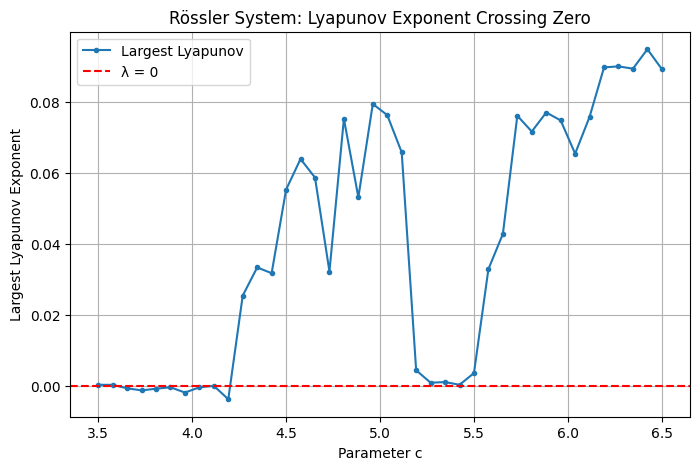

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# RK4 step
# =========================
def rossler_step(Y, a, b, c, dt):
    x, y, z, vx, vy, vz = Y

    def f(state):
        x, y, z, vx, vy, vz = state

        dx = -y - z
        dy = x + a*y
        dz = b + z*(x - c)

        # Jacobian
        dvx = -vy - vz
        dvy = vx + a*vy
        dvz = vz*(x - c) + z*vx

        return np.array([dx, dy, dz, dvx, dvy, dvz])

    k1 = f(Y)
    k2 = f(Y + 0.5*dt*k1)
    k3 = f(Y + 0.5*dt*k2)
    k4 = f(Y + dt*k3)

    return Y + dt*(k1 + 2*k2 + 2*k3 + k4)/6


# =========================
# Largest Lyapunov
# =========================
def largest_lyapunov(c, a=0.2, b=0.2,
                     dt=0.05, t_max=1000, transient=100):

    steps = int(t_max/dt)

    x0, y0, z0 = 1, 1, 1
    vx0, vy0, vz0 = 1e-8, 0, 0

    Y = np.array([x0, y0, z0, vx0, vy0, vz0])
    Y[3:] /= np.linalg.norm(Y[3:])

    sum_log = 0

    for i in range(steps):
        Y = rossler_step(Y, a, b, c, dt)

        v = Y[3:]
        norm_v = np.linalg.norm(v)

        if i*dt > transient:
            sum_log += np.log(norm_v)

        Y[3:] = v / norm_v

    return sum_log / (t_max - transient)


# =========================
# Parameter Scan
# =========================
cs = np.linspace(3.5, 6.5, 40)
lyap = []

for c in cs:
    print("Computing c =", c)
    lyap.append(largest_lyapunov(c))

lyap = np.array(lyap)

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))
plt.plot(cs, lyap, '.-', label="Largest Lyapunov")
plt.axhline(0, color='r', linestyle='--', label="λ = 0")

plt.xlabel("Parameter c")
plt.ylabel("Largest Lyapunov Exponent")
plt.title("Rössler System: Lyapunov Exponent Crossing Zero")
plt.legend()
plt.grid(True)
plt.show()


Computing c = 5.6
Computing c = 5.605128205128205
Computing c = 5.61025641025641
Computing c = 5.615384615384615
Computing c = 5.62051282051282
Computing c = 5.625641025641025
Computing c = 5.63076923076923
Computing c = 5.635897435897435
Computing c = 5.6410256410256405
Computing c = 5.646153846153846
Computing c = 5.651282051282051
Computing c = 5.656410256410256
Computing c = 5.661538461538461
Computing c = 5.666666666666666
Computing c = 5.671794871794871
Computing c = 5.676923076923076
Computing c = 5.682051282051281
Computing c = 5.6871794871794865
Computing c = 5.692307692307692
Computing c = 5.697435897435897
Computing c = 5.702564102564102
Computing c = 5.707692307692308
Computing c = 5.712820512820513
Computing c = 5.717948717948718
Computing c = 5.723076923076923
Computing c = 5.728205128205128
Computing c = 5.733333333333333
Computing c = 5.7384615384615385
Computing c = 5.743589743589744
Computing c = 5.748717948717949
Computing c = 5.753846153846154
Computing c = 5.758974

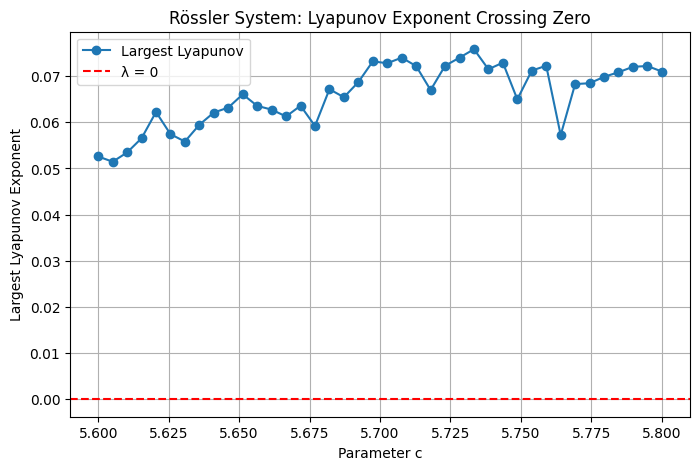

In [ ]:
# =========================
# Parameter Scan 2
# =========================
cs = np.linspace(5.6, 5.8, 40)
lyap = []

for c in cs:
    print("Computing c =", c)
    lyap.append(largest_lyapunov(c))

lyap = np.array(lyap)

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))
plt.plot(cs, lyap, 'o-', label="Largest Lyapunov")
plt.axhline(0, color='r', linestyle='--', label="λ = 0")

plt.xlabel("Parameter c")
plt.ylabel("Largest Lyapunov Exponent")
plt.title("Rössler System: Lyapunov Exponent Crossing Zero")
plt.legend()
plt.grid(True)
plt.show()


Computing beta = 0.5
Computing beta = 0.7435897435897436
Computing beta = 0.9871794871794872
Computing beta = 1.2307692307692308
Computing beta = 1.4743589743589745
Computing beta = 1.7179487179487178
Computing beta = 1.9615384615384615
Computing beta = 2.2051282051282053
Computing beta = 2.448717948717949
Computing beta = 2.692307692307692
Computing beta = 2.9358974358974357
Computing beta = 3.1794871794871793
Computing beta = 3.423076923076923
Computing beta = 3.6666666666666665
Computing beta = 3.91025641025641
Computing beta = 4.153846153846153
Computing beta = 4.397435897435898
Computing beta = 4.6410256410256405
Computing beta = 4.884615384615384
Computing beta = 5.128205128205128
Computing beta = 5.371794871794871
Computing beta = 5.615384615384615
Computing beta = 5.858974358974359
Computing beta = 6.102564102564102
Computing beta = 6.346153846153846
Computing beta = 6.589743589743589
Computing beta = 6.833333333333333
Computing beta = 7.076923076923077
Computing beta = 7.32051

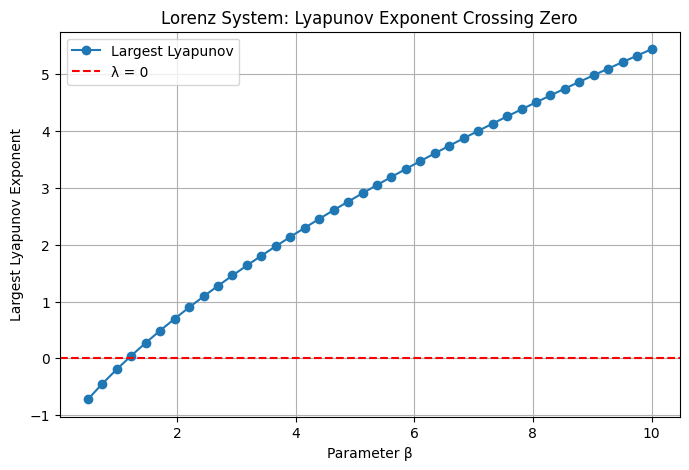

In [ ]:
# =========================
# RK4 step for Lorenz system
# =========================
def lorenz_step(Y, sigma, beta, rho, dt):
    x, y, z, vx, vy, vz = Y

    def f(state):
        x, y, z, vx, vy, vz = state

        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z

        # Jacobian
        dvx = sigma * (vy - vx)
        dvy = vx * (rho - vz) - vy
        dvz = vx * vy - beta * vz

        return np.array([dx, dy, dz, dvx, dvy, dvz])

    k1 = f(Y)
    k2 = f(Y + 0.5 * dt * k1)
    k3 = f(Y + 0.5 * dt * k2)
    k4 = f(Y + dt * k3)

    return Y + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6


# =========================
# Largest Lyapunov for Lorenz system
# =========================
def largest_lyapunov_lorenz(rho, sigma=10.0, beta=8/3.0, dt=0.01, t_max=10000, transient=1000):

    steps = int(t_max / dt)

    x0, y0, z0 = 1, 1, 1
    vx0, vy0, vz0 = 1e-8, 0, 0

    Y = np.array([x0, y0, z0, vx0, vy0, vz0])
    Y[3:] /= np.linalg.norm(Y[3:])

    sum_log = 0

    for i in range(steps):
        Y = lorenz_step(Y, sigma, beta, rho, dt)

        v = Y[3:]
        norm_v = np.linalg.norm(v)

        if i * dt > transient:
            sum_log += np.log(norm_v)

        Y[3:] = v / norm_v

    return sum_log / (t_max - transient)


# =========================
# Parameter Scan for beta
# =========================
betas = np.linspace(0.5, 10.0, 40)
lyap = []

for beta in betas:
    print("Computing beta =", beta)
    lyap.append(largest_lyapunov_lorenz(beta))

lyap = np.array(lyap)

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))
plt.plot(betas, lyap, 'o-', label="Largest Lyapunov")
plt.axhline(0, color='r', linestyle='--', label="λ = 0")

plt.xlabel("Parameter β")
plt.ylabel("Largest Lyapunov Exponent")
plt.title("Lorenz System: Lyapunov Exponent Crossing Zero")
plt.legend()
plt.grid(True)
plt.show()